In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
import statsmodels.stats.api as ssa
import statsmodels.api as sma
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder,StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score,auc,precision_recall_curve,confusion_matrix,classification_report
from sklearn.model_selection import GridSearchCV,cross_val_score
from sklearn.ensemble import RandomForestClassifier
import os
import joblib

warnings.filterwarnings('ignore')
PIPELINE='pipeline.pkl'
MODEL_FILE='model_file.pkl'
def built_pipeline(num_train,cat_train):
    num_pipeline=Pipeline([('impute',SimpleImputer(strategy='median')),('scaler',StandardScaler())])
    cat_pipeline=Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('encoder',OneHotEncoder(handle_unknown='ignore'))])
    merge_pipeline=ColumnTransformer([
        ('num_data',num_pipeline,list(num_train.columns)),
        ('cat_data',cat_pipeline,list(cat_train.columns))])
    return merge_pipeline
if not os.path.exists(MODEL_FILE):
    warnings.filterwarnings('ignore',category=UserWarning)
    data = pd.read_csv("retail_fraud_detection_100k.csv")
    num_data=data.select_dtypes(include=np.number)
    cat_data=data.select_dtypes(exclude=np.number)
    data['fraud_risk_label']=data['fraud_risk'].replace(to_replace=['Medium','Low','High'],value=[1,0,2])
    data=data.drop(['transaction_id','customer_id','fraud_risk'],axis=1)
    split=StratifiedShuffleSplit(n_splits=1,test_size=0.25,random_state=42)
    for train,test in split.split(data,data['fraud_risk_label']):
        strat_train=data.loc[train]
        strat_test=data.loc[test]
    train=strat_train.copy()
    test=strat_test.copy()
    train['fraud_risk_label']=train['fraud_risk_label'].astype(int)
    test['fraud_risk_label']=test['fraud_risk_label'].astype(int)
    train_label=train['fraud_risk_label']
    train=train.drop('fraud_risk_label',axis=1)
    test_label=test['fraud_risk_label']
    test=test.drop('fraud_risk_label',axis=1)
    drop=['transaction_amount','is_international','previous_fraud_flag','high_risk_device_flag','transaction_frequency_24h','avg_transaction_amount_7d','account_age_days','fraud_flag','transaction_timestamp','payment_method','location','merchant_category']
    train=train.drop(drop,axis=1)
    test=test.drop(drop,axis=1)
    num_train=train.select_dtypes(include=np.number)
    cat_train=train.select_dtypes(exclude=np.number)
    for i in num_train:
        q1,q3=np.quantile(train[i],[0.25,0.75])
        iqr=q3-q1
        ul=q3+(1.5*iqr)
        ll=q1-(1.5*iqr)
        ll,ul=np.quantile(train[i],[0.10,0.85])
        train.loc[train[i]>ul,i]=ul
        train.loc[train[i]<ll,i]=ll
    pipeline=built_pipeline(num_train,cat_train)
    prepared=pipeline.fit_transform(train,train_label)
    prepared_test=pipeline.transform(test)
    random_model=RandomForestClassifier(n_estimators=150,max_depth=5,class_weight='balanced',min_samples_leaf=50,random_state=42,n_jobs=-1)
    random_prepared=random_model.fit(prepared,train_label)
    prediction=random_prepared.predict(prepared_test)

    joblib.dump(random_prepared,MODEL_FILE)
    joblib.dump(pipeline,PIPELINE)
else:
    model=joblib.load(MODEL_FILE)
    pipeline=joblib.load(PIPELINE)
    transform_data=pipeline.transform(strat_test)
    prediction_test=model.predict(transform_data)
    prediction=pd.DataFrame(prediction_test,columns=['fraud_risk_predict'])
    prediction.to_csv('output_fraud_detect.csv')
    print('your project is ready for deployment')
    
    

your project is ready for deployment


In [7]:
full_prepared=Pipeline([
    ('preprocessing',pipeline),('rm_model',random_model)])
scoring=cross_val_score(full_prepared,train,train_label,cv=5,scoring='recall_weighted',n_jobs=-1)
scoring=(np.sum(scoring)/len(scoring))*100
print(scoring)


70.03866666666667


In [8]:
report=classification_report(test_label,prediction)
print(report)

              precision    recall  f1-score   support

           0       0.64      0.93      0.76      8051
           1       0.88      0.49      0.63     13053
           2       0.59      0.92      0.72      3896

    accuracy                           0.70     25000
   macro avg       0.70      0.78      0.70     25000
weighted avg       0.76      0.70      0.68     25000



In [9]:
accu=accuracy_score(test_label,prediction)
print('random forest model accuracy is :',accu*100)

random forest model accuracy is : 69.82000000000001


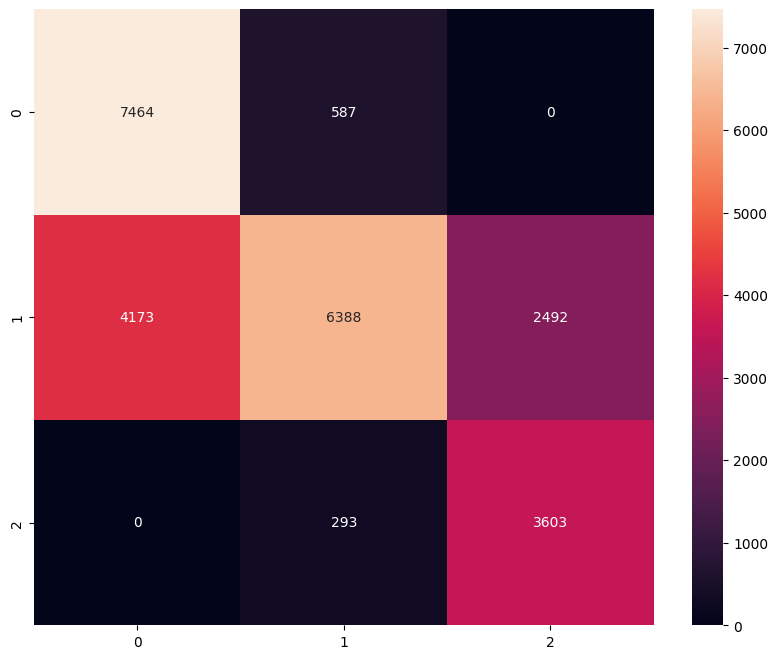

In [10]:
matrix=confusion_matrix(test_label,prediction)
plt.figure(figsize=(10,8))
sns.heatmap(matrix,annot=True,fmt='d')
plt.show()

In [11]:
# Here i am calculating pr-auc
y_random_prob=random_model.predict_proba(prepared_test)[:,2]
x_random_prob=(test_label==2)
precision_rand,recall_rand,_=precision_recall_curve(x_random_prob,y_random_prob)
auc_accuracy=auc(recall_rand,precision_rand)
print(auc_accuracy)

0.7547748626460292


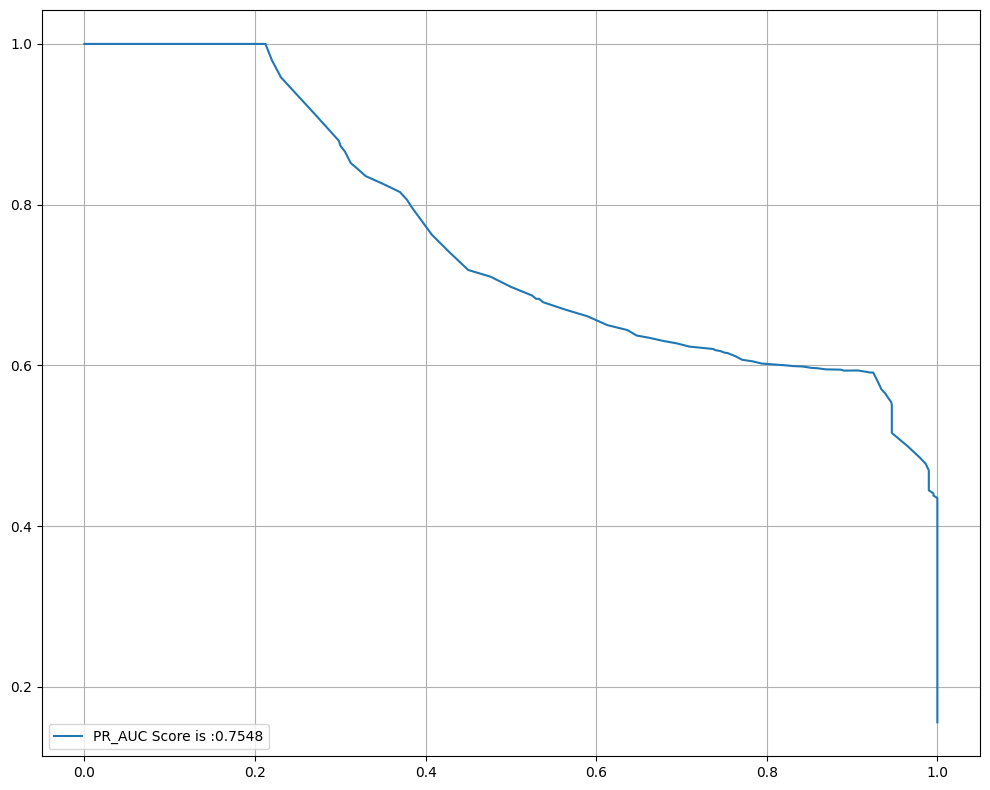

In [12]:
plt.figure(figsize=(10,8))
plt.plot(recall_rand,precision_rand,label=(f"PR_AUC Score is :{auc_accuracy:0.4f}"))
plt.legend(loc='lower left')
plt.grid()
plt.tight_layout()
plt.show()

In [14]:
# Feature Importance
values=random_prepared.feature_importances_
feature=pipeline.get_feature_names_out()
importance=pd.DataFrame({"feature":feature,'value':values}).sort_values(by='value',ascending=False)
print(importance)

                                      feature     value
2             num_data__unusual_location_flag  0.307255
1               num_data__unusual_amount_flag  0.232623
0      num_data__failed_transaction_count_24h  0.171369
3  num_data__multiple_transactions_short_time  0.157614
4                     num_data__velocity_flag  0.120495
6                cat_data__device_type_Mobile  0.007097
5               cat_data__device_type_Desktop  0.001840
7                cat_data__device_type_Tablet  0.001706
